# Fase D - Visualizaciones

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rutas_db = [Path('hurto_dw.db'), Path('entrega/hurto_dw.db')]
ruta_db = next((r for r in rutas_db if r.exists()), None)
if ruta_db is None:
    raise FileNotFoundError('No se encontró hurto_dw.db. Ejecute primero la Fase B.')

conn = sqlite3.connect(ruta_db)
print(f'Conectado a: {ruta_db.resolve()}')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

Conectado a: C:\Users\Diego Gomez\OneDrive\Escritorio\ciencia de datos\Laboratorio_CienciaDatos\entrega\hurto_dw.db


# 1. Serie de tiempo — Evolución mensual total de hurtos

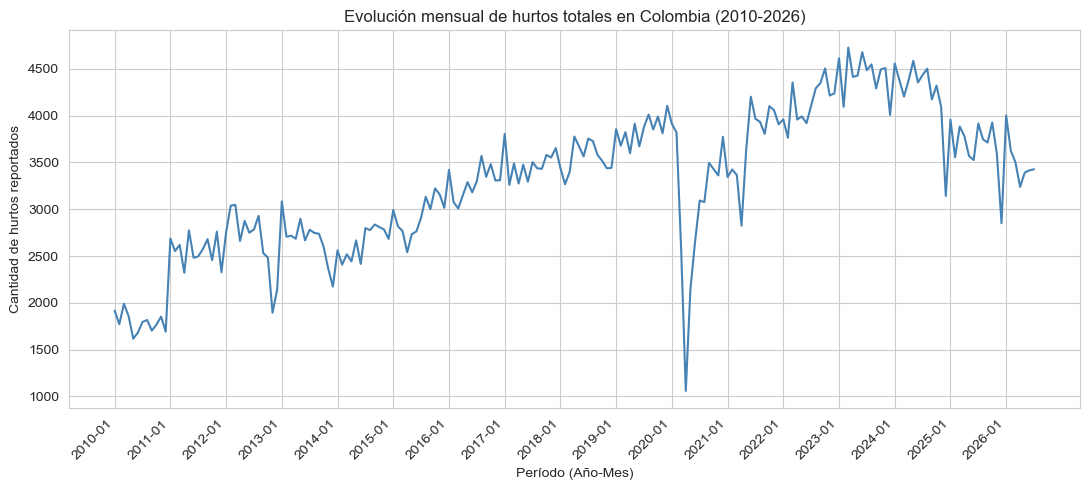

In [3]:
sql_1 = """
SELECT f.año_mes AS periodo, SUM(h.cantidad) AS total_hurtos
FROM fact_hurtos h
JOIN dim_fecha f ON h.fecha_key = f.fecha_key
GROUP BY f.año_mes
ORDER BY f.año_mes;
"""
df1 = pd.read_sql(sql_1, conn)

fig, ax = plt.subplots()
ax.plot(df1["periodo"], df1["total_hurtos"], color="steelblue", linewidth=1.5)
ax.set_title("Evolución mensual de hurtos totales en Colombia (2010-2026)")
ax.set_xlabel("Período (Año-Mes)")
ax.set_ylabel("Cantidad de hurtos reportados")
step = 12
ax.set_xticks(range(0, len(df1), step))
ax.set_xticklabels(df1["periodo"].iloc[::step], rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 2. Serie de tiempo — Motos vs. Automotores por mes

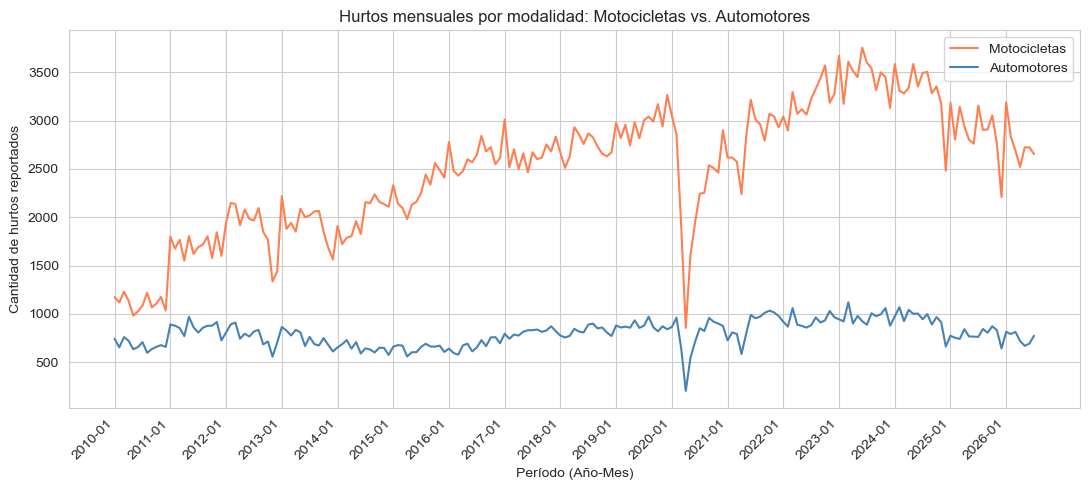

In [4]:
sql_2b = """
SELECT f.año_mes AS periodo, t.tipo_vehiculo AS modalidad, SUM(h.cantidad) AS total
FROM fact_hurtos h
JOIN dim_fecha f ON h.fecha_key = f.fecha_key
JOIN dim_tipo_hurto t ON h.tipo_hurto_key = t.tipo_hurto_key
GROUP BY f.año_mes, t.tipo_vehiculo
ORDER BY f.año_mes;
"""
df2b = pd.read_sql(sql_2b, conn)
pivot2b = df2b.pivot(index="periodo", columns="modalidad", values="total")

fig, ax = plt.subplots()
ax.plot(pivot2b.index, pivot2b["MOTOCICLETAS"], label="Motocicletas", color="coral")
ax.plot(pivot2b.index, pivot2b["AUTOMOTORES"], label="Automotores", color="steelblue")
ax.set_title("Hurtos mensuales por modalidad: Motocicletas vs. Automotores")
ax.set_xlabel("Período (Año-Mes)")
ax.set_ylabel("Cantidad de hurtos reportados")
ax.set_xticks(range(0, len(pivot2b), step))
ax.set_xticklabels(pivot2b.index[::step], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

# 3. Comparación categórica — Top 10 departamentos

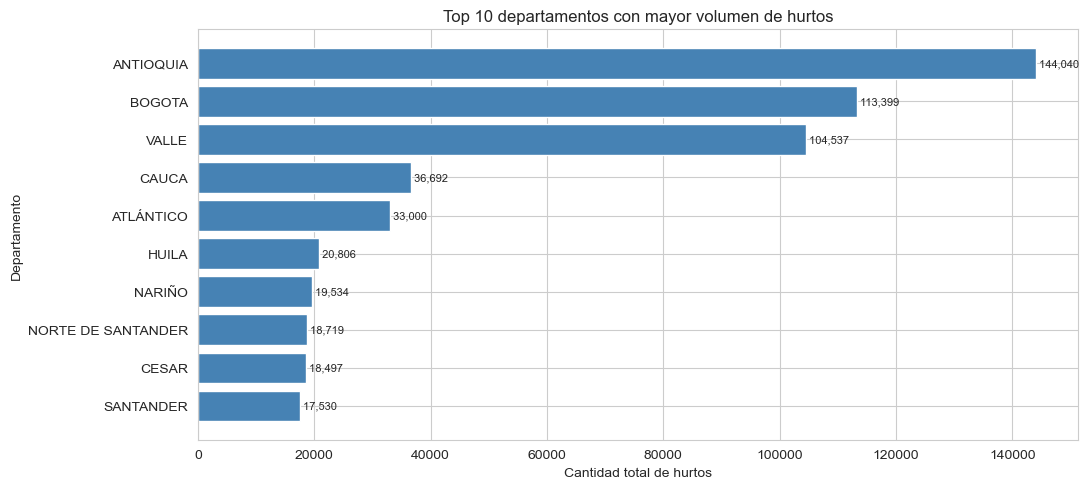

In [5]:
sql_3b = """
WITH total_nacional AS (SELECT SUM(cantidad) AS total FROM fact_hurtos)
SELECT m.departamento, SUM(h.cantidad) AS total_hurtos,
       ROUND(100.0 * SUM(h.cantidad) / total_nacional.total, 2) AS participacion_pct
FROM fact_hurtos h
JOIN dim_municipio m ON h.municipio_key = m.municipio_key
CROSS JOIN total_nacional
GROUP BY m.departamento
ORDER BY total_hurtos DESC
LIMIT 10;
"""
df3b = pd.read_sql(sql_3b, conn)

fig, ax = plt.subplots()
ax.barh(df3b["departamento"][::-1], df3b["total_hurtos"][::-1], color="steelblue")
ax.set_title("Top 10 departamentos con mayor volumen de hurtos")
ax.set_xlabel("Cantidad total de hurtos")
ax.set_ylabel("Departamento")
for i, v in enumerate(df3b["total_hurtos"][::-1]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

# 4. Comparación categórica — Top 10 municipios en hurtos de motos

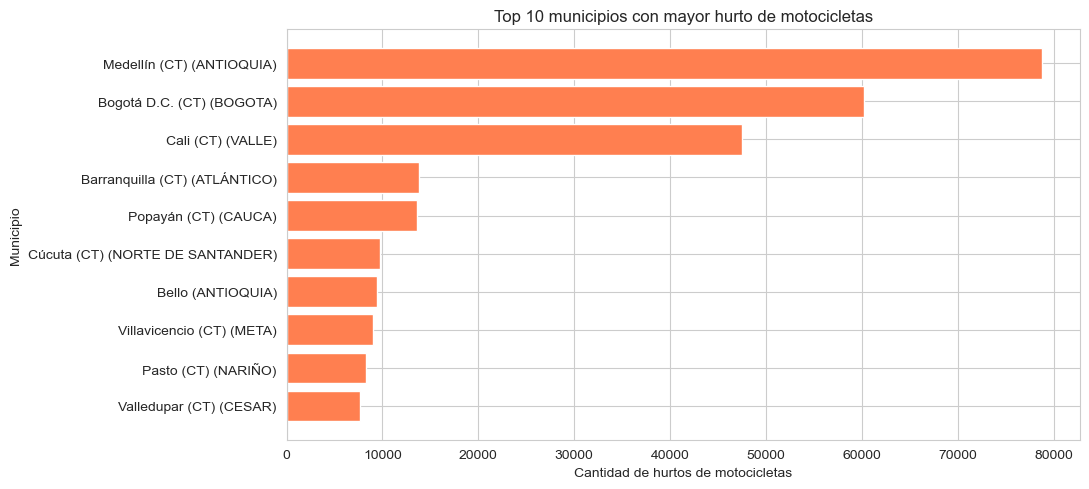

In [6]:
sql_4b = """
SELECT m.municipio, m.departamento, SUM(h.cantidad) AS hurtos_motos
FROM fact_hurtos h
JOIN dim_municipio m ON h.municipio_key = m.municipio_key
JOIN dim_tipo_hurto t ON h.tipo_hurto_key = t.tipo_hurto_key
WHERE t.tipo_vehiculo = 'MOTOCICLETAS'
GROUP BY m.municipio_key, m.municipio, m.departamento
ORDER BY hurtos_motos DESC
LIMIT 10;
"""
df4b = pd.read_sql(sql_4b, conn)
etiquetas = df4b["municipio"] + " (" + df4b["departamento"] + ")"

fig, ax = plt.subplots()
ax.barh(etiquetas[::-1], df4b["hurtos_motos"][::-1], color="coral")
ax.set_title("Top 10 municipios con mayor hurto de motocicletas")
ax.set_xlabel("Cantidad de hurtos de motocicletas")
ax.set_ylabel("Municipio")
plt.tight_layout()
plt.show()

# 5. Comparación categórica — Top 5 armas/medios

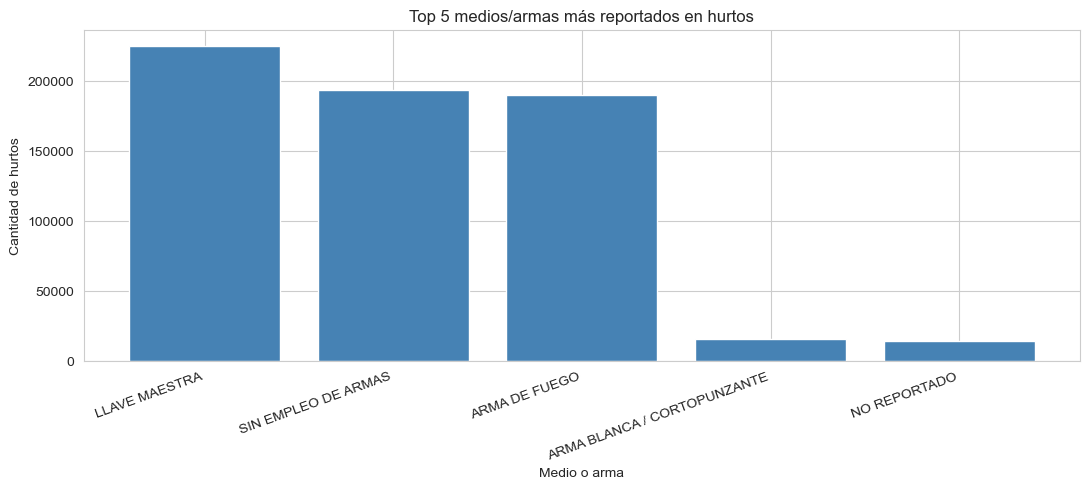

In [7]:
sql_5b = """
SELECT a.arma_medio, SUM(h.cantidad) AS total_hurtos
FROM fact_hurtos h
JOIN dim_arma_medio a ON h.arma_medio_key = a.arma_medio_key
GROUP BY a.arma_medio_key, a.arma_medio
ORDER BY total_hurtos DESC
LIMIT 5;
"""
df5b = pd.read_sql(sql_5b, conn)

fig, ax = plt.subplots()
ax.bar(df5b["arma_medio"], df5b["total_hurtos"], color="steelblue")
ax.set_title("Top 5 medios/armas más reportados en hurtos")
ax.set_xlabel("Medio o arma")
ax.set_ylabel("Cantidad de hurtos")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# 6. Relación bivariada — Heatmap de estacionalidad (mes × año)

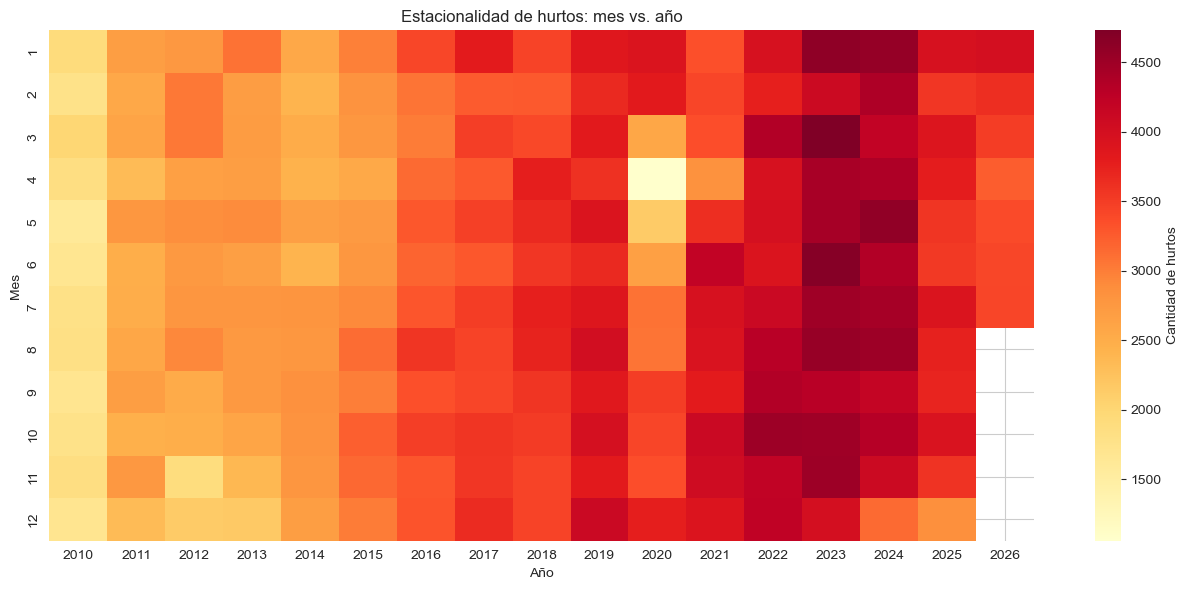

In [8]:
sql_6b = """
SELECT f.año, f.mes, SUM(h.cantidad) AS total_hurtos
FROM fact_hurtos h
JOIN dim_fecha f ON h.fecha_key = f.fecha_key
GROUP BY f.año, f.mes
ORDER BY f.año, f.mes;
"""
df6b = pd.read_sql(sql_6b, conn)
pivot6b = df6b.pivot(index="mes", columns="año", values="total_hurtos")

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot6b, cmap="YlOrRd", annot=False, ax=ax, cbar_kws={"label": "Cantidad de hurtos"})
ax.set_title("Estacionalidad de hurtos: mes vs. año")
ax.set_xlabel("Año")
ax.set_ylabel("Mes")
plt.tight_layout()
plt.show()

# 7. Relación bivariada — Volumen vs. alcance territorial por departamento

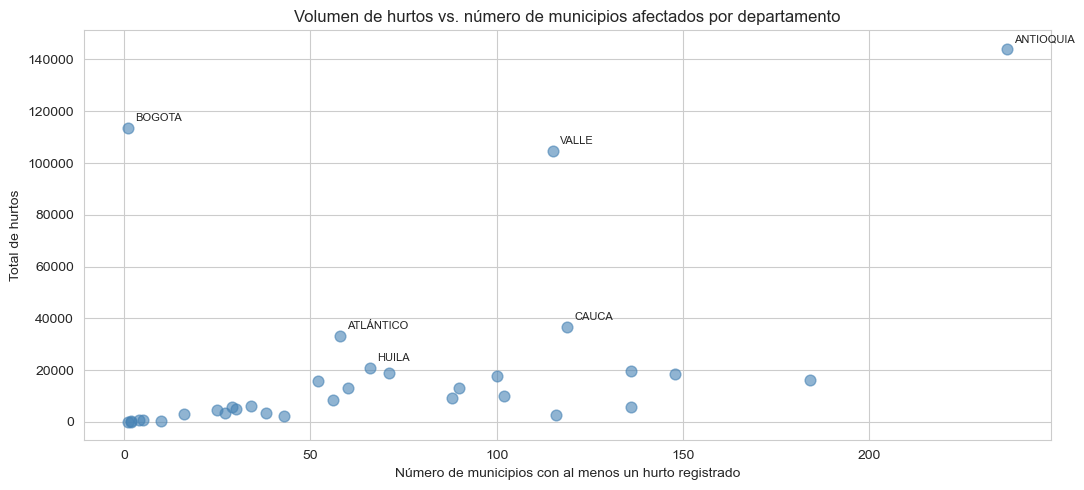

In [9]:
sql_7b = """
SELECT m.departamento, SUM(h.cantidad) AS total_hurtos,
       COUNT(DISTINCT m.municipio_key) AS municipios_afectados
FROM fact_hurtos h
JOIN dim_municipio m ON h.municipio_key = m.municipio_key
GROUP BY m.departamento;
"""
df7b = pd.read_sql(sql_7b, conn)

fig, ax = plt.subplots()
ax.scatter(df7b["municipios_afectados"], df7b["total_hurtos"], alpha=0.6, s=60, color="steelblue")
for _, row in df7b.nlargest(6, "total_hurtos").iterrows():
    ax.annotate(row["departamento"], (row["municipios_afectados"], row["total_hurtos"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")
ax.set_title("Volumen de hurtos vs. número de municipios afectados por departamento")
ax.set_xlabel("Número de municipios con al menos un hurto registrado")
ax.set_ylabel("Total de hurtos")
plt.tight_layout()
plt.show()

# 8. Distribución univariada — Boxplot de totales mensuales por año

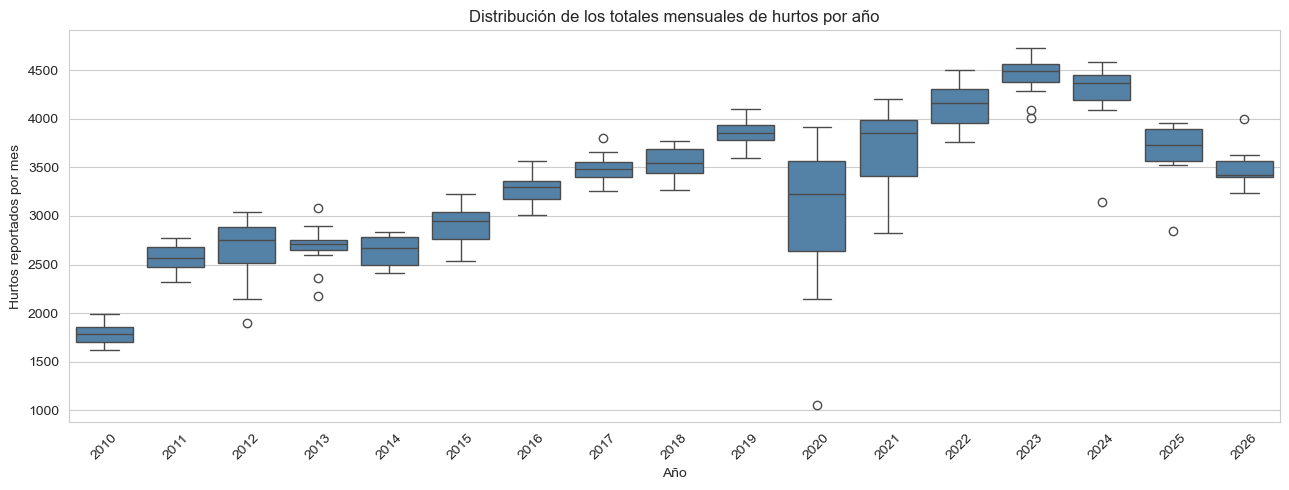

In [10]:
sql_8b = """
SELECT f.año, f.mes, SUM(h.cantidad) AS total_mensual
FROM fact_hurtos h
JOIN dim_fecha f ON h.fecha_key = f.fecha_key
GROUP BY f.año, f.mes;
"""
df8b = pd.read_sql(sql_8b, conn)

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df8b, x="año", y="total_mensual", ax=ax, color="steelblue")
ax.set_title("Distribución de los totales mensuales de hurtos por año")
ax.set_xlabel("Año")
ax.set_ylabel("Hurtos reportados por mes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
conn.close()
print("Conexión SQLite cerrada correctamente.")

Conexión SQLite cerrada correctamente.
